**Importing libraries**

In [1]:
import pandas as pd # for dataframes
import matplotlib.pyplot as plt # for plotting graphs
import seaborn as sns # for plotting graphs
import datetime as dt
import numpy as np

**Reading data**

In [2]:
data = pd.read_excel("custrandata.xlsx")

In [3]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
filtereddata = data[['Country', 'Customer ID']].drop_duplicates()

**Customers across top 10 countries**

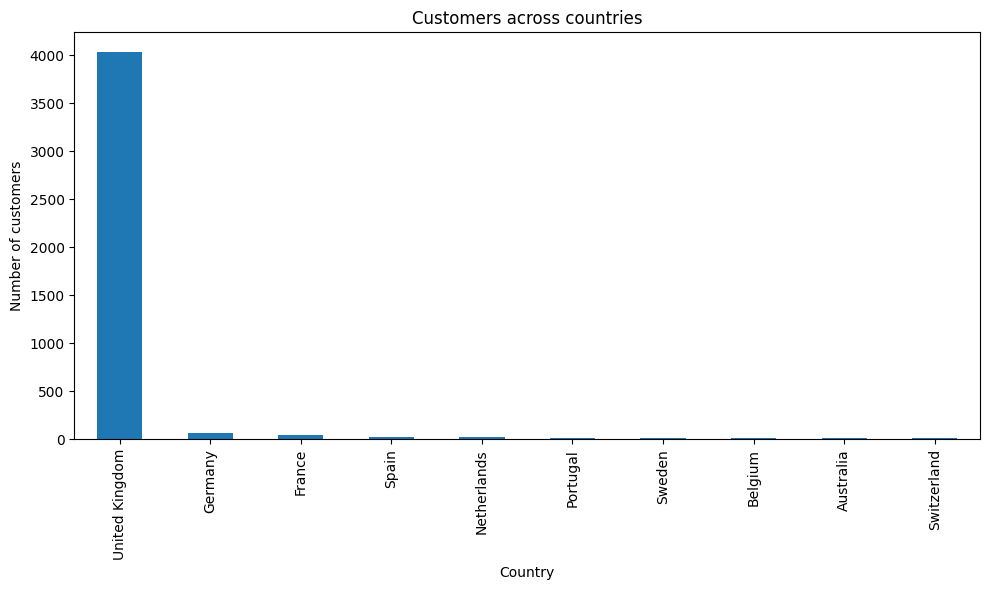

In [5]:
filtereddata.Country.value_counts()[:10].plot(kind='bar')
plt.ylabel('Number of customers')
plt.title('Customers across countries')
plt.gcf().set_size_inches(10, 6)
plt.tight_layout()
plt.savefig('C:/Users/USER/Desktop/Analysis/customersvcountries.jpg')
plt.show()

In [6]:
uk_data = data[data.Country=='United Kingdom']
uk_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 485852 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      485852 non-null  object        
 1   StockCode    485852 non-null  object        
 2   Description  482924 non-null  object        
 3   Quantity     485852 non-null  int64         
 4   InvoiceDate  485852 non-null  datetime64[ns]
 5   Price        485852 non-null  float64       
 6   Customer ID  379423 non-null  float64       
 7   Country      485852 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.4+ MB


In [7]:
uk_data.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,485852.000000,485852,485852.000000,379423.000000
mean,9.116039,2010-06-27 21:41:53.628553472,4.543470,15559.935694
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-19 13:01:00,1.250000,14210.000000
50%,3.000000,2010-07-05 12:09:00,2.100000,15581.000000
75%,10.000000,2010-10-15 14:52:00,4.210000,16938.000000
max,10200.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,85.883463,NaN,149.623198,1593.744626


In [8]:
uk_data = uk_data[(uk_data['Quantity']>0)]
uk_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 474938 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      474938 non-null  object        
 1   StockCode    474938 non-null  object        
 2   Description  473837 non-null  object        
 3   Quantity     474938 non-null  int64         
 4   InvoiceDate  474938 non-null  datetime64[ns]
 5   Price        474938 non-null  float64       
 6   Customer ID  370951 non-null  float64       
 7   Country      474938 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.6+ MB


In [9]:
df = pd.DataFrame(uk_data[['InvoiceDate', 'Price', 'Quantity']])
df['TotalPurchase'] = df['Quantity']*df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Period'] = df['InvoiceDate'].dt.to_period('M')
df['Period'] = df['Period'].astype(str)
Revenue = df.groupby('Period')['TotalPurchase'].sum().reset_index()
df = Revenue
df = df[df['Period'].str.startswith('2010')]
df

,Period,TotalPurchase
1,2010-01,511797.662
2,2010-02,455136.286
3,2010-03,721530.211
4,2010-04,531015.371
5,2010-05,560187.810
6,2010-06,652412.490
7,2010-07,515410.750
8,2010-08,596550.350
9,2010-09,773073.501
10,2010-10,961483.010


**Revenue in Year 2010**

C:\Users\USER\AppData\Local\Temp\ipykernel_5772\2085569079.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = pd.to_datetime(df['Period'] + '-01').dt.strftime('%b')


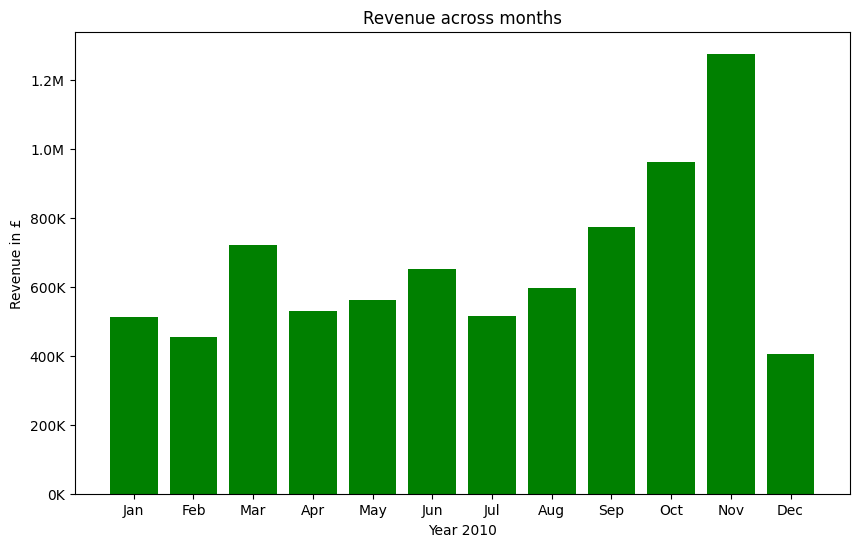

In [10]:
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(10, 6))
df['Month'] = pd.to_datetime(df['Period'] + '-01').dt.strftime('%b')
plt.bar(df['Month'], df['TotalPurchase'], color='green')
plt.title('Revenue across months')
plt.xlabel('Year 2010')
plt.ylabel('Revenue in £')
def custom_formatter(x, pos):
    if x >= 1000000:
        return f'{x/1000000:.1f}M'
    else:
        return f'{int(x/1000)}K'
formatter = FuncFormatter(custom_formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.savefig('C:/Users/USER/Desktop/Analysis/revenuevmonths.jpg')
plt.show()

In [11]:
df = pd.DataFrame(uk_data[['InvoiceDate', 'Quantity']])
df['Sales'] = df['Quantity']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Period'] = df['InvoiceDate'].dt.to_period('M')
df['Period'] = df['Period'].astype(str)
Sales = df.groupby('Period')['Sales'].sum().reset_index()
df = Sales
df = df[df['Period'].str.startswith('2010')]
df

,Period,Sales
1,2010-01,262110
2,2010-02,253609
3,2010-03,410561
4,2010-04,323538
5,2010-05,366860
6,2010-06,355990
7,2010-07,312976
8,2010-08,382281
9,2010-09,504903
10,2010-10,527393


**Sales in year 2010**

C:\Users\USER\AppData\Local\Temp\ipykernel_5772\1302359490.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = pd.to_datetime(df['Period'] + '-01').dt.strftime('%b')


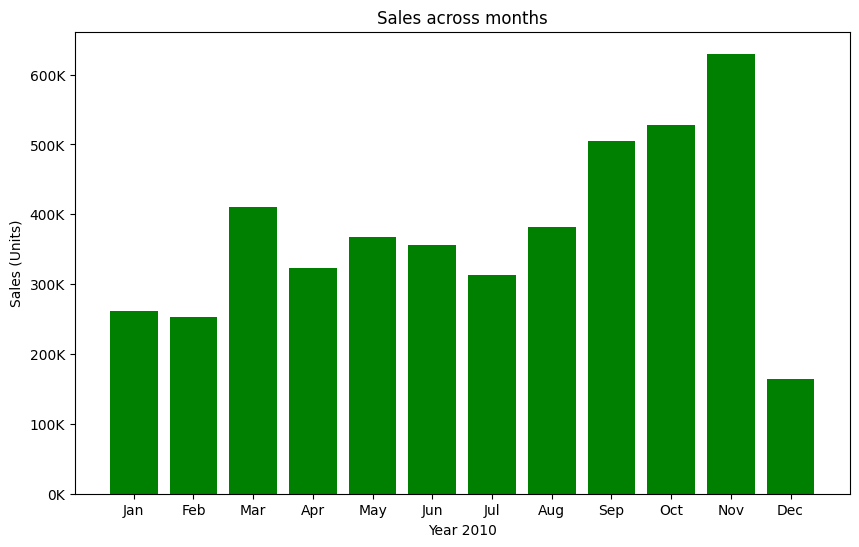

In [12]:
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(10, 6))
df['Month'] = pd.to_datetime(df['Period'] + '-01').dt.strftime('%b')
plt.bar(df['Month'], df['Sales'], color='green')
plt.title('Sales across months')
plt.xlabel('Year 2010')
plt.ylabel('Sales (Units)')
formatter = FuncFormatter(lambda x, _: f'{int(x/1000)}K')
plt.gca().yaxis.set_major_formatter(formatter)
plt.savefig('C:/Users/USER/Desktop/Analysis/salesvmonths.jpg')
plt.show()

In [13]:
uk_data = uk_data[['Customer ID', 'InvoiceDate', 'Invoice', 'Quantity', 'Price']]

In [14]:
uk_data['TotalPurchase'] = uk_data['Quantity']*uk_data['Price']

In [15]:
uk_data_group=uk_data.groupby('Customer ID').agg({'InvoiceDate': lambda date: (date.max() - date.min()).days,
                                                 'Invoice': lambda num: len(num),
                                                 'Quantity': lambda quant: quant.sum(),
                                                 'TotalPurchase': lambda price: price.sum()})

In [16]:
uk_data_group.head()

,InvoiceDate,Invoice,Quantity,TotalPurchase
Customer ID,,,,
12346.0,196,33,70,372.86
12608.0,0,16,323,415.79
12745.0,87,22,467,723.85
12746.0,0,17,97,254.55
12747.0,363,154,1483,5080.53


In [17]:
uk_data_group.columns = ['num_days', 'num_transactions', 'num_units', 'spent_money']
uk_data_group.head()

,num_days,num_transactions,num_units,spent_money
Customer ID,,,,
12346.0,196,33,70,372.86
12608.0,0,16,323,415.79
12745.0,87,22,467,723.85
12746.0,0,17,97,254.55
12747.0,363,154,1483,5080.53


In [18]:
uk_data_group['avg_order_value'] = uk_data_group['spent_money']/uk_data_group['num_transactions']

In [19]:
uk_data_group.head()

,num_days,num_transactions,num_units,spent_money,avg_order_value
Customer ID,,,,,
12346.0,196,33,70,372.86,11.298788
12608.0,0,16,323,415.79,25.986875
12745.0,87,22,467,723.85,32.902273
12746.0,0,17,97,254.55,14.973529
12747.0,363,154,1483,5080.53,32.990455


In [20]:
purchase_frequency = sum(uk_data_group['num_transactions'])/uk_data_group.shape[0]

In [21]:
repeat_rate = uk_data_group[uk_data_group.num_transactions > 1].shape[0]/uk_data_group.shape[0]

In [22]:
churn_rate=1-repeat_rate

In [23]:
purchase_frequency, repeat_rate,churn_rate

(93.41500881390078, 0.9788466381264165, 0.02115336187358352)

In [24]:
uk_data_group['profit_margin'] = uk_data_group['spent_money']*0.05

In [25]:
uk_data_group.head()

,num_days,num_transactions,num_units,spent_money,avg_order_value,profit_margin
Customer ID,,,,,,
12346.0,196,33,70,372.86,11.298788,18.6430
12608.0,0,16,323,415.79,25.986875,20.7895
12745.0,87,22,467,723.85,32.902273,36.1925
12746.0,0,17,97,254.55,14.973529,12.7275
12747.0,363,154,1483,5080.53,32.990455,254.0265


In [26]:
uk_data_group['CLV']= (uk_data_group['avg_order_value']*purchase_frequency)/churn_rate

In [27]:
uk_data_group['cust_lifetime_value'] = uk_data_group['CLV']*uk_data_group['profit_margin']

In [28]:
uk_data_group.head()

,num_days,num_transactions,num_units,spent_money,avg_order_value,profit_margin,CLV,cust_lifetime_value
Customer ID,,,,,,,,
12346.0,196,33,70,372.86,11.298788,18.6430,49896.388838,9.302184e+05
12608.0,0,16,323,415.79,25.986875,20.7895,114760.205573,2.385807e+06
12745.0,87,22,467,723.85,32.902273,36.1925,145299.178220,5.258741e+06
12746.0,0,17,97,254.55,14.973529,12.7275,66124.353676,8.415977e+05
12747.0,363,154,1483,5080.53,32.990455,254.0265,145688.596477,3.700876e+07


In [29]:
uk_data.head()

,Customer ID,InvoiceDate,Invoice,Quantity,Price,TotalPurchase
0,13085.0,2009-12-01 07:45:00,489434,12,6.95,83.4
1,13085.0,2009-12-01 07:45:00,489434,12,6.75,81.0
2,13085.0,2009-12-01 07:45:00,489434,12,6.75,81.0
3,13085.0,2009-12-01 07:45:00,489434,48,2.10,100.8
4,13085.0,2009-12-01 07:45:00,489434,24,1.25,30.0


In [30]:
uk_data['month_yr'] = uk_data['InvoiceDate'].apply(lambda x: x.strftime('%b-%Y'))

In [31]:
uk_data.head()

,Customer ID,InvoiceDate,Invoice,Quantity,Price,TotalPurchase,month_yr
0,13085.0,2009-12-01 07:45:00,489434,12,6.95,83.4,Dec-2009
1,13085.0,2009-12-01 07:45:00,489434,12,6.75,81.0,Dec-2009
2,13085.0,2009-12-01 07:45:00,489434,12,6.75,81.0,Dec-2009
3,13085.0,2009-12-01 07:45:00,489434,48,2.10,100.8,Dec-2009
4,13085.0,2009-12-01 07:45:00,489434,24,1.25,30.0,Dec-2009


In [32]:
sale = uk_data.pivot_table(index=['Customer ID'], columns=['month_yr'], values = 'TotalPurchase', aggfunc='sum', fill_value=0).reset_index()

In [33]:
sale.head()

month_yr,Customer ID,Apr-2010,Aug-2010,Dec-2009,Dec-2010,Feb-2010,Jan-2010,Jul-2010,Jun-2010,Mar-2010,May-2010,Nov-2010,Oct-2010,Sep-2010
0,12346.0,0.00,0.00,113.5,0.00,0.0,90.0,0.0,142.31,27.05,0.00,0.00,0.00,0.0
1,12608.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,415.79,0.0
2,12745.0,0.00,266.93,0.0,0.00,0.0,0.0,0.0,0.00,0.00,456.92,0.00,0.00,0.0
3,12746.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,254.55,0.00,0.00,0.00,0.00,0.0
4,12747.0,213.28,629.68,1032.0,358.56,260.0,0.0,0.0,666.25,210.89,267.37,394.75,1047.75,0.0


In [34]:
sale['CLV'] = sale.iloc[:, 2:].sum(axis = 1)

In [35]:
sale.head()

month_yr,Customer ID,Apr-2010,Aug-2010,Dec-2009,Dec-2010,Feb-2010,Jan-2010,Jul-2010,Jun-2010,Mar-2010,May-2010,Nov-2010,Oct-2010,Sep-2010,CLV
0,12346.0,0.00,0.00,113.5,0.00,0.0,90.0,0.0,142.31,27.05,0.00,0.00,0.00,0.0,372.86
1,12608.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,415.79,0.0,415.79
2,12745.0,0.00,266.93,0.0,0.00,0.0,0.0,0.0,0.00,0.00,456.92,0.00,0.00,0.0,723.85
3,12746.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,254.55,0.00,0.00,0.00,0.00,0.0,254.55
4,12747.0,213.28,629.68,1032.0,358.56,260.0,0.0,0.0,666.25,210.89,267.37,394.75,1047.75,0.0,4867.25


In [36]:
X = sale[['Jan-2010', 'Feb-2010', 'Mar-2010', 'Apr-2010', 'May-2010', 'Jun-2010', 'Jul-2010', 'Aug-2010', 'Sep-2010', 'Oct-2010', 'Nov-2010', 'Dec-2010']]
y=sale[['CLV']]

**Linear Regression**

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , random_state =0)

In [38]:
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)

In [39]:
print(linreg.intercept_)
np.array(linreg.coef_)

[11.18890444]


array([[1.50663351, 1.14783154, 1.21400573, 0.04128252, 1.02451084,
        0.91281311, 0.98627608, 1.02892164, 1.02633261, 1.00648735,
        1.03334181, 1.42950962]])

Text(0.5, 1.0, 'Linear Regression Model for CLV')

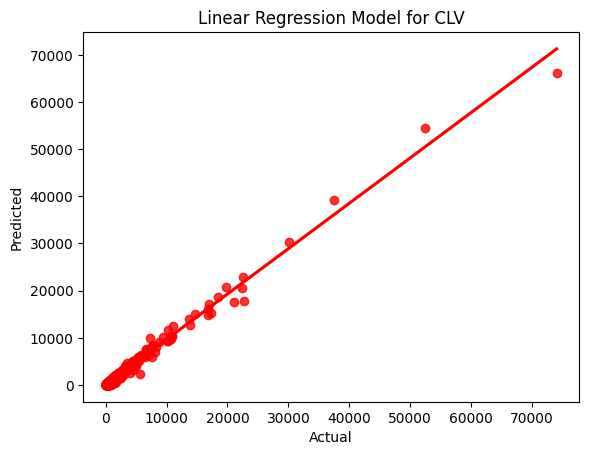

In [40]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red')
plt.ylabel('Predicted')
plt.xlabel('Actual')
plt.title('Linear Regression Model for CLV')

In [41]:
X.shape


(3971, 12)

In [42]:
x_mean = X.iloc[0:3971].mean()
x_mean.values

array([104.91947671, 103.52000403, 148.50793528, 126.77555805,
       126.79000755, 136.32784185, 126.98058927, 128.05038781,
       171.64083883, 221.40253085, 247.71521833,  70.17269957])

**CLV in 2010**

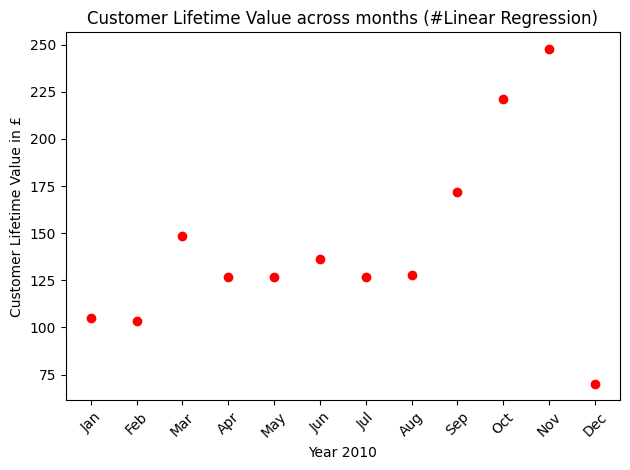

In [44]:
x = np.array([104.91947671, 103.52000403, 148.50793528, 126.77555805,
              126.79000755, 136.32784185, 126.98058927, 128.05038781,
              171.64083883, 221.40253085, 247.71521833, 70.17269957])
coefficients = np.array([1.50663351, 1.14783154, 1.21400573, 0.04128252, 1.02451084,
                        0.91281311, 0.98627608, 1.02892164, 1.02633261, 1.00648735,
                        1.03334181, 1.42950962])

plt.scatter(range(len(x)), x, color='r', label='Original Data Points')

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(len(months)), months, rotation=45)

plt.xlabel('Year 2010')
plt.ylabel('Customer Lifetime Value in £')
plt.title('Customer Lifetime Value across months (#Linear Regression)')

formatter = FuncFormatter(lambda x, _: f'{int(x)}') 
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.savefig('C:/Users/USER/Desktop/Analysis/CLVvmonths.jpg')
plt.show()